# Step 6. 시장 레짐 감지 + 경보 시스템

**Hidden Markov Model (HMM)** 기반 시장 레짐 감지와 **4단계 경보 시스템**을 구축합니다.

---

## 목적

| 구분 | 설명 |
|------|------|
| **레짐 감지** | 시장이 어떤 "숨겨진 상태"에 있는지 확률적으로 추정 |
| **경보 시스템** | 스트레스 수준을 0~3 레벨로 정량화하여 리스크 관리 트리거 제공 |

## HMM 개요

- **핵심 아이디어**: 시장은 관측할 수 없는(hidden) 상태(레짐)들 사이를 전환하며, 각 상태에서 서로 다른 분포의 데이터를 생성한다.
- **입력 변수 (5개)**: VIX_level, VIX_contango, HY_spread, yield_curve, Cu_Au_ratio_chg
- **모델 선택**: BIC(Bayesian Information Criterion)으로 최적 상태 수 결정 (n=2,3,4 비교)

## 경보 시스템 (4 Config)

| Config | 설명 |
|--------|------|
| **A** | VIX 단독 기반 (20/28/35 임계값) |
| **B** | A + VIX 백워데이션 보정 |
| **C** | 복합 스트레스 점수 (7개 변수 가중합) + 독립 트리거 |
| **D** | C + 디바운싱 (5일 중 3일 이상 확인) |

> **주의**: 이 Step에서는 전체 표본(full-sample) 탐색적 분석을 수행합니다.  
> Step7(Walk-Forward 통합)에서 IS 윈도우 내에서만 HMM을 훈련하여 look-ahead bias를 방지합니다.

In [1]:
# ============================================================
# 라이브러리 임포트 + 데이터 로드
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import os, warnings

warnings.filterwarnings('ignore')

# ── 시각화 설정 ──
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# ── 경로 설정 ──
V3_DIR   = os.getcwd()  # PJ12_v3_Final/
DATA_DIR = os.path.join(V3_DIR, 'data')
IMG_DIR  = os.path.join(V3_DIR, 'images')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

# ── 데이터 로드 ──
df_reg = pd.read_csv(os.path.join(DATA_DIR, 'df_reg_v2.csv'), index_col='Date', parse_dates=True)
print(f'df_reg_v2: {df_reg.shape}')
print(f'기간: {df_reg.index[0].date()} ~ {df_reg.index[-1].date()}')
print(f'컬럼 수: {len(df_reg.columns)}')

df_reg_v2: (2328, 44)
기간: 2016-12-29 ~ 2025-12-31
컬럼 수: 44


---
## 6-1. 다변량 HMM (Hidden Markov Model)

**Hidden Markov Model**은 "숨겨진 상태가 전환되며 데이터를 생성하는 모형"입니다.

### 핵심 가정
1. 시장에는 관측할 수 없는 K개의 레짐(상태)이 존재한다.
2. 각 레짐에서 관측 변수는 서로 다른 다변량 정규분포를 따른다.
3. 레짐 간 전이는 마르코프 성질을 만족한다 (현재 상태만이 다음 상태를 결정).

### 입력 변수

| 변수 | 역할 |
|------|------|
| VIX_level | 내재 변동성 수준 (공포 지수) |
| VIX_contango | VIX 기간구조 (정상 > 0, 백워데이션 < 0) |
| HY_spread | 하이일드 신용스프레드 (신용 리스크) |
| yield_curve | 10Y-2Y 수익률 곡선 (경기 사이클) |
| Cu_Au_ratio_chg | 구리/금 비율 변화 (경기 기대 vs 안전선호) |

### BIC 기반 모델 선택
- n=2 (안전/위험), n=3 (안전/보통/위험), n=4 (세분화)
- 각 n마다 10개 random seed로 학습 → 최고 log-likelihood 모델 선택
- BIC = -2·LL + k·log(T)로 과적합 방지

In [2]:
# ============================================================
# 6-1. HMM 학습 + BIC 기반 모델 선택
# ============================================================

HMM_FEATURES = ['VIX_level', 'VIX_contango', 'HY_spread', 'yield_curve', 'Cu_Au_ratio_chg']
X_raw = df_reg[HMM_FEATURES].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f'HMM 입력: {X_raw.shape[0]}일 x {X_raw.shape[1]}변수')
print(f'피처: {HMM_FEATURES}')
print()

# ── BIC 모델 선택 (n=2,3,4) ──
bic_results = []
for n in [2, 3, 4]:
    best_score = -np.inf
    best_model = None
    for seed in range(10):
        model = GaussianHMM(
            n_components=n, covariance_type='full',
            n_iter=500, random_state=seed, tol=1e-4
        )
        model.fit(X_scaled)
        score = model.score(X_scaled)
        if score > best_score:
            best_score = score
            best_model = model
    # BIC 계산
    d = X_scaled.shape[1]
    k = n * (n - 1) + n * d + n * d * (d + 1) // 2
    bic = -2 * best_score + k * np.log(len(X_scaled))
    bic_results.append({'n': n, 'LL': best_score, 'k': k, 'BIC': bic, 'model': best_model})
    print(f'  n={n}: LL={best_score:,.1f}, k={k}, BIC={bic:,.1f}')

# 최적 모델 선택 (BIC 최소)
bic_df = pd.DataFrame(bic_results)
best_idx = bic_df['BIC'].idxmin()
best_n = bic_df.loc[best_idx, 'n']
hmm_model = bic_df.loc[best_idx, 'model']
print(f'\n최적 모델: n={best_n} (BIC={bic_df.loc[best_idx, "BIC"]:,.1f})')

# ── 레짐 레이블링 (VIX 평균 오름차순) ──
raw_states = hmm_model.predict(X_scaled)

# 각 상태의 VIX 평균 계산 → 오름차순 정렬
vix_col_idx = HMM_FEATURES.index('VIX_level')
state_vix_means = {}
for s in range(best_n):
    mask = raw_states == s
    state_vix_means[s] = X_raw.iloc[mask]['VIX_level'].mean()

sorted_states = sorted(state_vix_means, key=state_vix_means.get)
label_map = {old: new for new, old in enumerate(sorted_states)}
regime_labels = np.array([label_map[s] for s in raw_states])

# df_reg에 레짐 추가
df_reg.loc[X_raw.index, 'hmm_regime'] = regime_labels
print(f'\n레짐 레이블 매핑 (VIX 평균 오름차순): {label_map}')

HMM 입력: 2328일 x 5변수
피처: ['VIX_level', 'VIX_contango', 'HY_spread', 'yield_curve', 'Cu_Au_ratio_chg']



  n=2: LL=-12,356.4, k=42, BIC=25,038.5


  n=3: LL=-10,625.9, k=66, BIC=21,763.4


  n=4: LL=-9,631.6, k=92, BIC=19,976.5

최적 모델: n=4 (BIC=19,976.5)

레짐 레이블 매핑 (VIX 평균 오름차순): {0: 0, 2: 1, 1: 2, 3: 3}


In [3]:
# ============================================================
# 레짐 통계 + 전이 행렬
# ============================================================

regime_data = df_reg.dropna(subset=['hmm_regime']).copy()
regime_data['hmm_regime'] = regime_data['hmm_regime'].astype(int)

print('=' * 65)
print('레짐별 통계')
print('=' * 65)

regime_stats = []
for r in sorted(regime_data['hmm_regime'].unique()):
    subset = regime_data[regime_data['hmm_regime'] == r]
    days = len(subset)
    pct = days / len(regime_data) * 100
    avg_vix = subset['VIX_level'].mean()
    avg_hy = subset['HY_spread'].mean()
    avg_yc = subset['yield_curve'].mean()
    avg_rv = subset['rv_neutral'].mean()
    regime_stats.append({
        'Regime': r,
        'Days': days,
        '%': f'{pct:.1f}%',
        'Avg VIX': f'{avg_vix:.1f}',
        'Avg HY Spread': f'{avg_hy:.2f}',
        'Avg Yield Curve': f'{avg_yc:.2f}',
        'Avg rv_neutral': f'{avg_rv:.4f}',
    })

stats_df = pd.DataFrame(regime_stats)
print(stats_df.to_string(index=False))

# ── 전이 행렬 ──
print('\n' + '=' * 65)
print('레짐 전이 행렬 (Transition Matrix)')
print('=' * 65)

# HMM 모델의 전이 행렬을 레이블 재정렬하여 표시
raw_transmat = hmm_model.transmat_
reordered_transmat = np.zeros_like(raw_transmat)
inv_map = {v: k for k, v in label_map.items()}
for i in range(best_n):
    for j in range(best_n):
        reordered_transmat[i, j] = raw_transmat[inv_map[i], inv_map[j]]

regime_names = [f'Regime {i}' for i in range(best_n)]
trans_df = pd.DataFrame(reordered_transmat, index=regime_names, columns=regime_names)
print(trans_df.round(4).to_string())

레짐별 통계
 Regime  Days     % Avg VIX Avg HY Spread Avg Yield Curve Avg rv_neutral
      0   470 20.2%    12.3          3.63            0.69         0.0666
      1   702 30.2%    19.2          3.17            0.68         0.1019
      2   729 31.3%    19.9          4.34           -0.24         0.1272
      3   427 18.3%    22.3          4.48            0.24         0.1625

레짐 전이 행렬 (Transition Matrix)
          Regime 0  Regime 1  Regime 2  Regime 3
Regime 0    0.9915    0.0043    0.0000    0.0042
Regime 1    0.0029    0.9928    0.0000    0.0043
Regime 2    0.0000    0.0027    0.9959    0.0014
Regime 3    0.0024    0.0047    0.0070    0.9859


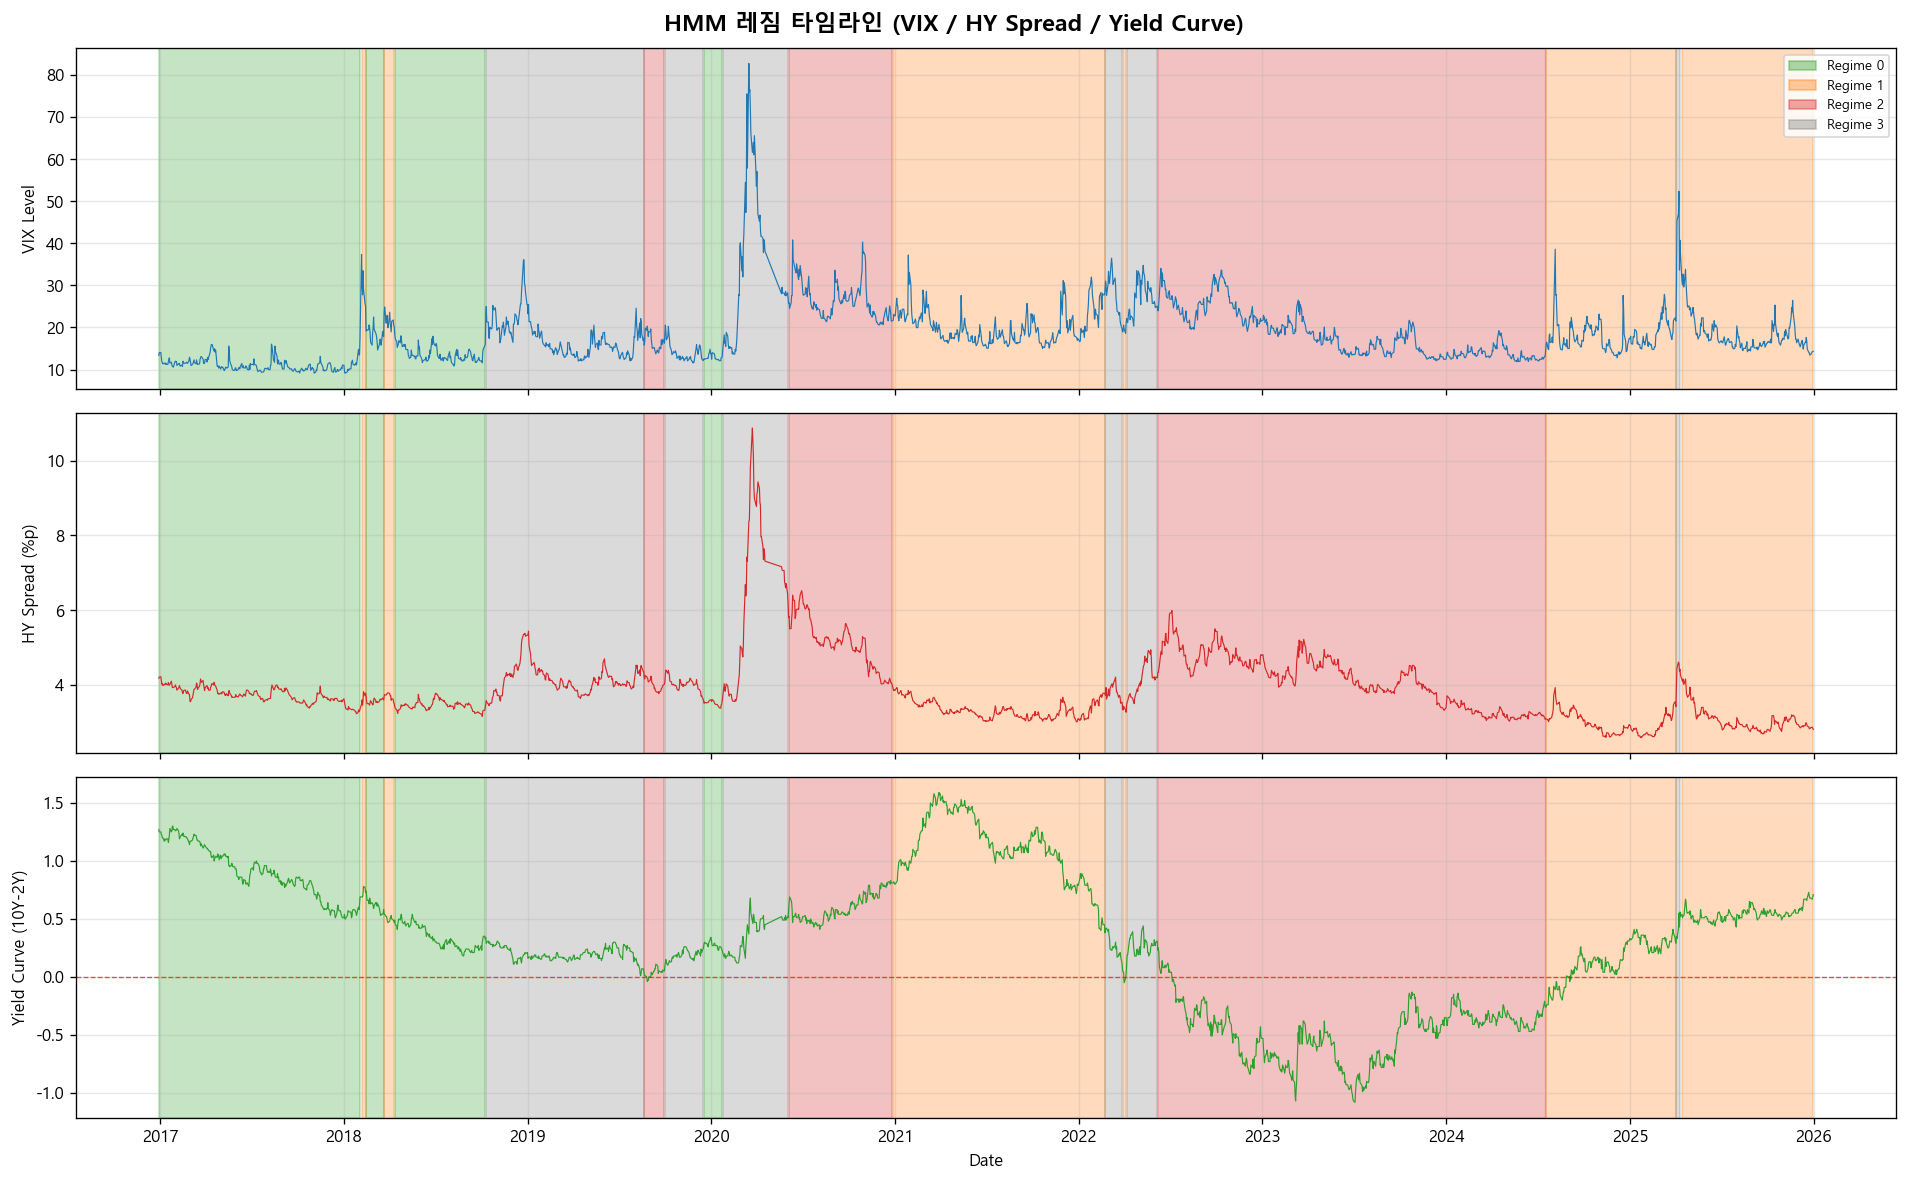

저장: images/step6_01_regime_timeline.png


In [4]:
# ============================================================
# 시각화: 레짐 타임라인 (VIX + HY + YC + 레짐 음영)
# ============================================================

regime_colors = {
    0: '#2ca02c',   # 안전 (녹색)
    1: '#ff7f0e',   # 보통 (주황)
    2: '#d62728',   # 위험 (빨강)
    3: '#7f7f7f',   # 극위험 (회색) - n=4인 경우
}

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('HMM 레짐 타임라인 (VIX / HY Spread / Yield Curve)', fontsize=14, fontweight='bold')

plot_data = regime_data.copy()
series_list = [
    ('VIX_level', 'VIX Level', '#1f77b4'),
    ('HY_spread', 'HY Spread (%p)', '#d62728'),
    ('yield_curve', 'Yield Curve (10Y-2Y)', '#2ca02c'),
]

for ax, (col, ylabel, color) in zip(axes, series_list):
    ax.plot(plot_data.index, plot_data[col], linewidth=0.7, color=color, zorder=2)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(alpha=0.3, zorder=0)
    
    # 레짐 음영
    for r in sorted(plot_data['hmm_regime'].unique()):
        r = int(r)
        mask = plot_data['hmm_regime'] == r
        ax.fill_between(
            plot_data.index, ax.get_ylim()[0], ax.get_ylim()[1],
            where=mask, alpha=0.15, color=regime_colors.get(r, '#999999'),
            zorder=0
        )
    
    # y축 범위 재설정 (음영 후)
    ymin, ymax = plot_data[col].min(), plot_data[col].max()
    margin = (ymax - ymin) * 0.05
    ax.set_ylim(ymin - margin, ymax + margin)
    
    # 레짐 음영 재적용 (올바른 y축 범위)
    for r in sorted(plot_data['hmm_regime'].unique()):
        r = int(r)
        mask = plot_data['hmm_regime'] == r
        ax.fill_between(
            plot_data.index, ymin - margin, ymax + margin,
            where=mask, alpha=0.15, color=regime_colors.get(r, '#999999'),
            zorder=0
        )

# Yield curve 0선
axes[2].axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

# 범례
legend_patches = [mpatches.Patch(color=regime_colors.get(r, '#999999'), alpha=0.4,
                                  label=f'Regime {r}')
                  for r in sorted(plot_data['hmm_regime'].unique())]
axes[0].legend(handles=legend_patches, loc='upper right', fontsize=8)

axes[2].set_xlabel('Date')
plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step6_01_regime_timeline.png'), bbox_inches='tight')
plt.show()
print('저장: images/step6_01_regime_timeline.png')

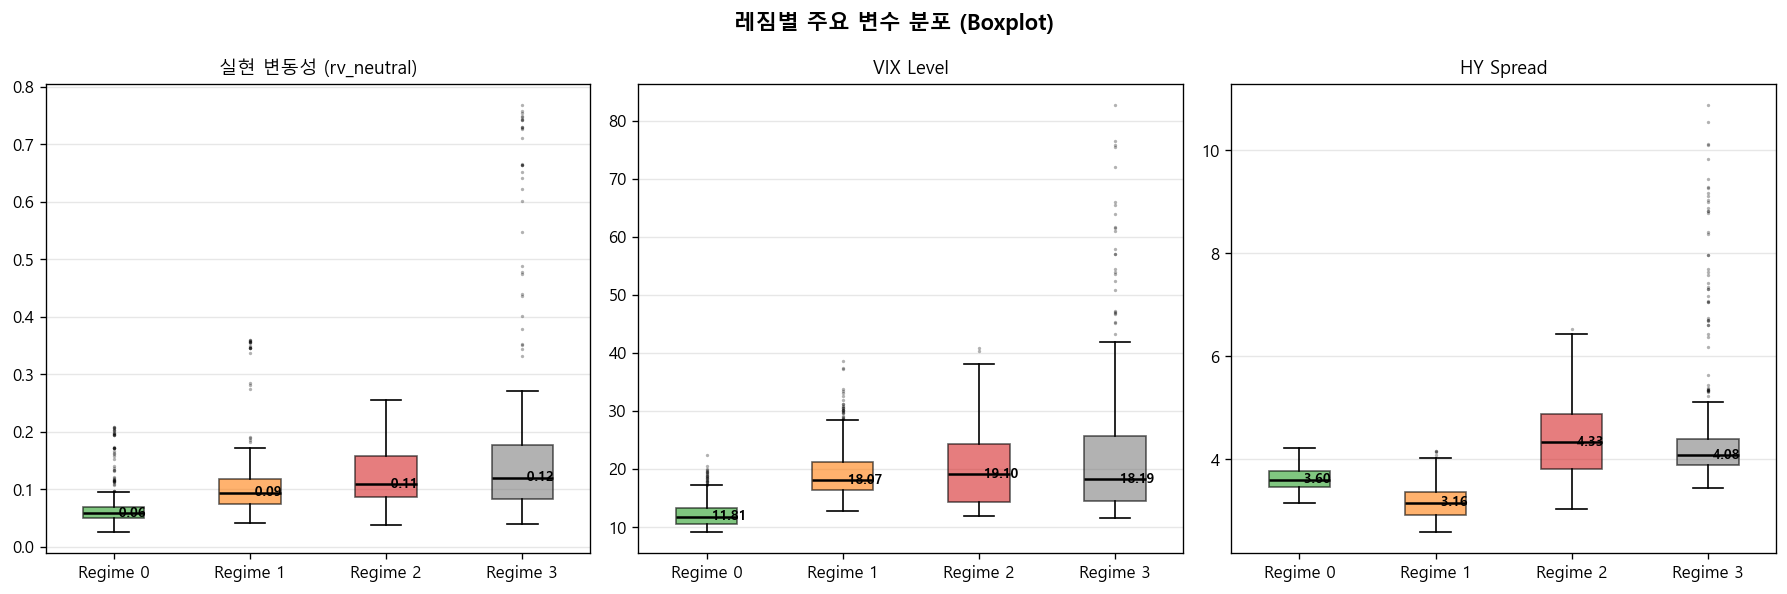

저장: images/step6_02_regime_volatility.png


In [5]:
# ============================================================
# 시각화: 레짐별 변동성 Boxplot
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('레짐별 주요 변수 분포 (Boxplot)', fontsize=13, fontweight='bold')

box_vars = [
    ('rv_neutral', '실현 변동성 (rv_neutral)'),
    ('VIX_level', 'VIX Level'),
    ('HY_spread', 'HY Spread'),
]

for ax, (col, title) in zip(axes, box_vars):
    valid = regime_data[[col, 'hmm_regime']].dropna()
    n_regimes = sorted(valid['hmm_regime'].unique())
    box_colors = [regime_colors.get(int(r), '#999999') for r in n_regimes]
    
    bp = ax.boxplot(
        [valid[valid['hmm_regime'] == r][col].values for r in n_regimes],
        labels=[f'Regime {int(r)}' for r in n_regimes],
        patch_artist=True,
        flierprops=dict(marker='.', markersize=2, alpha=0.3),
        medianprops=dict(color='black', linewidth=1.5),
    )
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    # 중앙값 표시
    for i, r in enumerate(n_regimes):
        med = valid[valid['hmm_regime'] == r][col].median()
        ax.text(i + 1, med, f' {med:.2f}', va='center', fontsize=8, fontweight='bold')
    
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step6_02_regime_volatility.png'), bbox_inches='tight')
plt.show()
print('저장: images/step6_02_regime_volatility.png')

---
## 6-2. 경보 시스템 (4 Config)

### 설계 원칙

1. **VIX 우선 원칙**: VIX는 시장 공포를 가장 직관적이고 즉시적으로 반영하는 지표이므로, Config A/B의 핵심 기준으로 사용합니다.
2. **점진적 복잡화**: A(단순) → B(보정) → C(복합) → D(디바운싱) 순으로 신호 품질을 개선합니다.
3. **독립 트리거**: 수익률 곡선 역전, Sahm Rule 발동 등은 복합 점수와 무관하게 경보를 발생시킵니다.

### 경보 레벨 정의

| Level | 의미 | 대응 |
|-------|------|------|
| 0 | 정상 | 포트폴리오 유지 |
| 1 | 주의 | 모니터링 강화 |
| 2 | 경고 | 방어 포지션 전환 검토 |
| 3 | 위험 | 즉시 방어 포지션 전환 |

### Config 상세

| Config | 로직 |
|--------|------|
| **A** | VIX >= 35 → 3, >= 28 → 2, >= 20 → 1, else 0 |
| **B** | A의 결과 + VIX 백워데이션(contango < 0) 시 +1 |
| **C** | 7변수 가중 스트레스 점수(0~100) + 백분위 임계값(p75/p90/p97) + 독립 트리거 |
| **D** | C + 디바운싱: 최근 5일 중 3일 이상 동일 레벨 확인 시에만 유지 |

In [6]:
# ============================================================
# 6-2. 경보 시스템 함수 정의 (4 Config)
# ============================================================

# ── Config A: VIX 단독 ──
def alert_config_a(row):
    """VIX 수준만으로 경보 레벨 결정"""
    vix = row.get('VIX_level', 15)
    if vix >= 35: return 3
    elif vix >= 28: return 2
    elif vix >= 20: return 1
    return 0


# ── Config B: VIX + Contango ──
def alert_config_b(row):
    """Config A + VIX 백워데이션 보정"""
    level = alert_config_a(row)
    if row.get('VIX_contango', 0) < 0:  # backwardation
        level = min(level + 1, 3)
    return level


# ── Config C: 복합 스트레스 점수 + 독립 트리거 ──
SCORE_COMPONENTS = {
    'VIX_level':       {'weight': 0.25, 'dir': +1, 'lo': 12, 'hi': 45},
    'VIX_contango':    {'weight': 0.15, 'dir': -1, 'lo': -0.15, 'hi': 0.10},
    'HY_spread':       {'weight': 0.20, 'dir': +1, 'lo': 2.5, 'hi': 8.0},
    'yield_curve':     {'weight': 0.10, 'dir': -1, 'lo': -0.5, 'hi': 2.5},
    'SKEW_level':      {'weight': 0.10, 'dir': +1, 'lo': 110, 'hi': 170},
    'claims_zscore':   {'weight': 0.10, 'dir': +1, 'lo': -2, 'hi': 3},
    'Cu_Au_ratio_chg': {'weight': 0.10, 'dir': -1, 'lo': -0.10, 'hi': 0.05},
}


def compute_stress_score(row, date=None):
    """7개 변수 가중합 기반 스트레스 점수 (0~100)"""
    score = 0
    total_weight = 0
    for feat, cfg in SCORE_COMPONENTS.items():
        val = row.get(feat, np.nan)
        if np.isnan(val):
            continue
        normed = np.clip((val - cfg['lo']) / (cfg['hi'] - cfg['lo']), 0, 1)
        if cfg['dir'] < 0:
            normed = 1 - normed
        score += cfg['weight'] * normed * 100
        total_weight += cfg['weight']
    # 결측 변수가 있으면 가용 가중치로 재정규화
    if total_weight > 0 and total_weight < 1.0:
        score = score / total_weight
    return score


def alert_config_c(row, p75, p90, p97):
    """복합 스트레스 점수 + 독립 트리거"""
    score = compute_stress_score(row)
    
    # 백분위 기반 임계값
    level = 0
    if score >= p97:
        level = 3
    elif score >= p90:
        level = 2
    elif score >= p75:
        level = 1
    
    # 독립 트리거 (구조적 이벤트)
    hy_chg = row.get('HY_spread_chg', 0)
    if abs(hy_chg) > 0.5:
        level = max(level, 1)
    
    yc = row.get('yield_curve', 1)
    if yc < 0:
        level = max(level, 1)
    
    sahm = row.get('sahm_indicator', 0)
    if sahm >= 0.50:
        level = max(level, 2)
    
    contango = row.get('VIX_contango', 0)
    if contango < -0.05:
        level = max(level, 1)
    
    return level, score


# ── Config D: C + 디바운싱 ──
def debounce_alerts(raw_alerts, window=5, threshold=3):
    """최근 window일 중 threshold일 이상 동일 레벨 이상이어야 유지"""
    debounced = raw_alerts.copy()
    for i in range(window, len(raw_alerts)):
        recent = raw_alerts.iloc[i - window:i]
        current = raw_alerts.iloc[i]
        if (recent >= current).sum() < threshold:
            debounced.iloc[i] = max(0, current - 1)
    return debounced


print('경보 함수 정의 완료')
print(f'  Config A: VIX 단독 (임계값 20/28/35)')
print(f'  Config B: A + VIX 백워데이션 보정')
print(f'  Config C: 7변수 복합 스트레스 점수 + 독립 트리거')
print(f'  Config D: C + 디바운싱 (5일 중 3일)')
print(f'\n스트레스 점수 구성요소:')
for feat, cfg in SCORE_COMPONENTS.items():
    dir_str = '↑ 위험' if cfg['dir'] > 0 else '↓ 위험'
    print(f'  {feat:20s} | 가중치 {cfg["weight"]:.2f} | {dir_str} | [{cfg["lo"]} ~ {cfg["hi"]}]')

경보 함수 정의 완료
  Config A: VIX 단독 (임계값 20/28/35)
  Config B: A + VIX 백워데이션 보정
  Config C: 7변수 복합 스트레스 점수 + 독립 트리거
  Config D: C + 디바운싱 (5일 중 3일)

스트레스 점수 구성요소:
  VIX_level            | 가중치 0.25 | ↑ 위험 | [12 ~ 45]
  VIX_contango         | 가중치 0.15 | ↓ 위험 | [-0.15 ~ 0.1]
  HY_spread            | 가중치 0.20 | ↑ 위험 | [2.5 ~ 8.0]
  yield_curve          | 가중치 0.10 | ↓ 위험 | [-0.5 ~ 2.5]
  SKEW_level           | 가중치 0.10 | ↑ 위험 | [110 ~ 170]
  claims_zscore        | 가중치 0.10 | ↑ 위험 | [-2 ~ 3]
  Cu_Au_ratio_chg      | 가중치 0.10 | ↓ 위험 | [-0.1 ~ 0.05]


In [7]:
# ============================================================
# 4 Config 적용
# ============================================================

# Config A, B: 직접 적용
df_reg['alert_a'] = df_reg.apply(alert_config_a, axis=1)
df_reg['alert_b'] = df_reg.apply(alert_config_b, axis=1)

# Config C: 롤링 500일 윈도우로 백분위 계산
# 먼저 전체 스트레스 점수 계산
stress_scores = df_reg.apply(lambda row: compute_stress_score(row), axis=1)
df_reg['stress_score'] = stress_scores

# 롤링 백분위 계산 (expanding 500일 → 안정화 후 rolling)
rolling_p75 = stress_scores.rolling(window=500, min_periods=250).quantile(0.75)
rolling_p90 = stress_scores.rolling(window=500, min_periods=250).quantile(0.90)
rolling_p97 = stress_scores.rolling(window=500, min_periods=250).quantile(0.97)

# Config C 적용
alert_c_levels = []
alert_c_scores = []
for idx in df_reg.index:
    row = df_reg.loc[idx]
    p75 = rolling_p75.get(idx, np.nan)
    p90 = rolling_p90.get(idx, np.nan)
    p97 = rolling_p97.get(idx, np.nan)
    
    if np.isnan(p75):
        alert_c_levels.append(0)
        alert_c_scores.append(row.get('stress_score', 0))
    else:
        level, score = alert_config_c(row, p75, p90, p97)
        alert_c_levels.append(level)
        alert_c_scores.append(score)

df_reg['alert_c'] = alert_c_levels

# Config D: C + 디바운싱
df_reg['alert_d'] = debounce_alerts(df_reg['alert_c'], window=5, threshold=3)

# ── 분포 출력 ──
print('=' * 65)
print('경보 레벨 분포 (4 Config 비교)')
print('=' * 65)

for config in ['alert_a', 'alert_b', 'alert_c', 'alert_d']:
    dist = df_reg[config].value_counts().sort_index()
    total = dist.sum()
    print(f'\n{config.upper()}:')
    for level, count in dist.items():
        pct = count / total * 100
        bar = '█' * int(pct / 2)
        print(f'  Level {int(level)}: {count:5d}일 ({pct:5.1f}%) {bar}')

경보 레벨 분포 (4 Config 비교)

ALERT_A:
  Level 0:  1583일 ( 68.0%) █████████████████████████████████
  Level 1:   546일 ( 23.5%) ███████████
  Level 2:   144일 (  6.2%) ███
  Level 3:    55일 (  2.4%) █

ALERT_B:
  Level 0:  1568일 ( 67.4%) █████████████████████████████████
  Level 1:   487일 ( 20.9%) ██████████
  Level 2:   182일 (  7.8%) ███
  Level 3:    91일 (  3.9%) █

ALERT_C:
  Level 0:  1099일 ( 47.2%) ███████████████████████
  Level 1:   687일 ( 29.5%) ██████████████
  Level 2:   434일 ( 18.6%) █████████
  Level 3:   108일 (  4.6%) ██

ALERT_D:
  Level 0:  1162일 ( 49.9%) ████████████████████████
  Level 1:   677일 ( 29.1%) ██████████████
  Level 2:   424일 ( 18.2%) █████████
  Level 3:    65일 (  2.8%) █


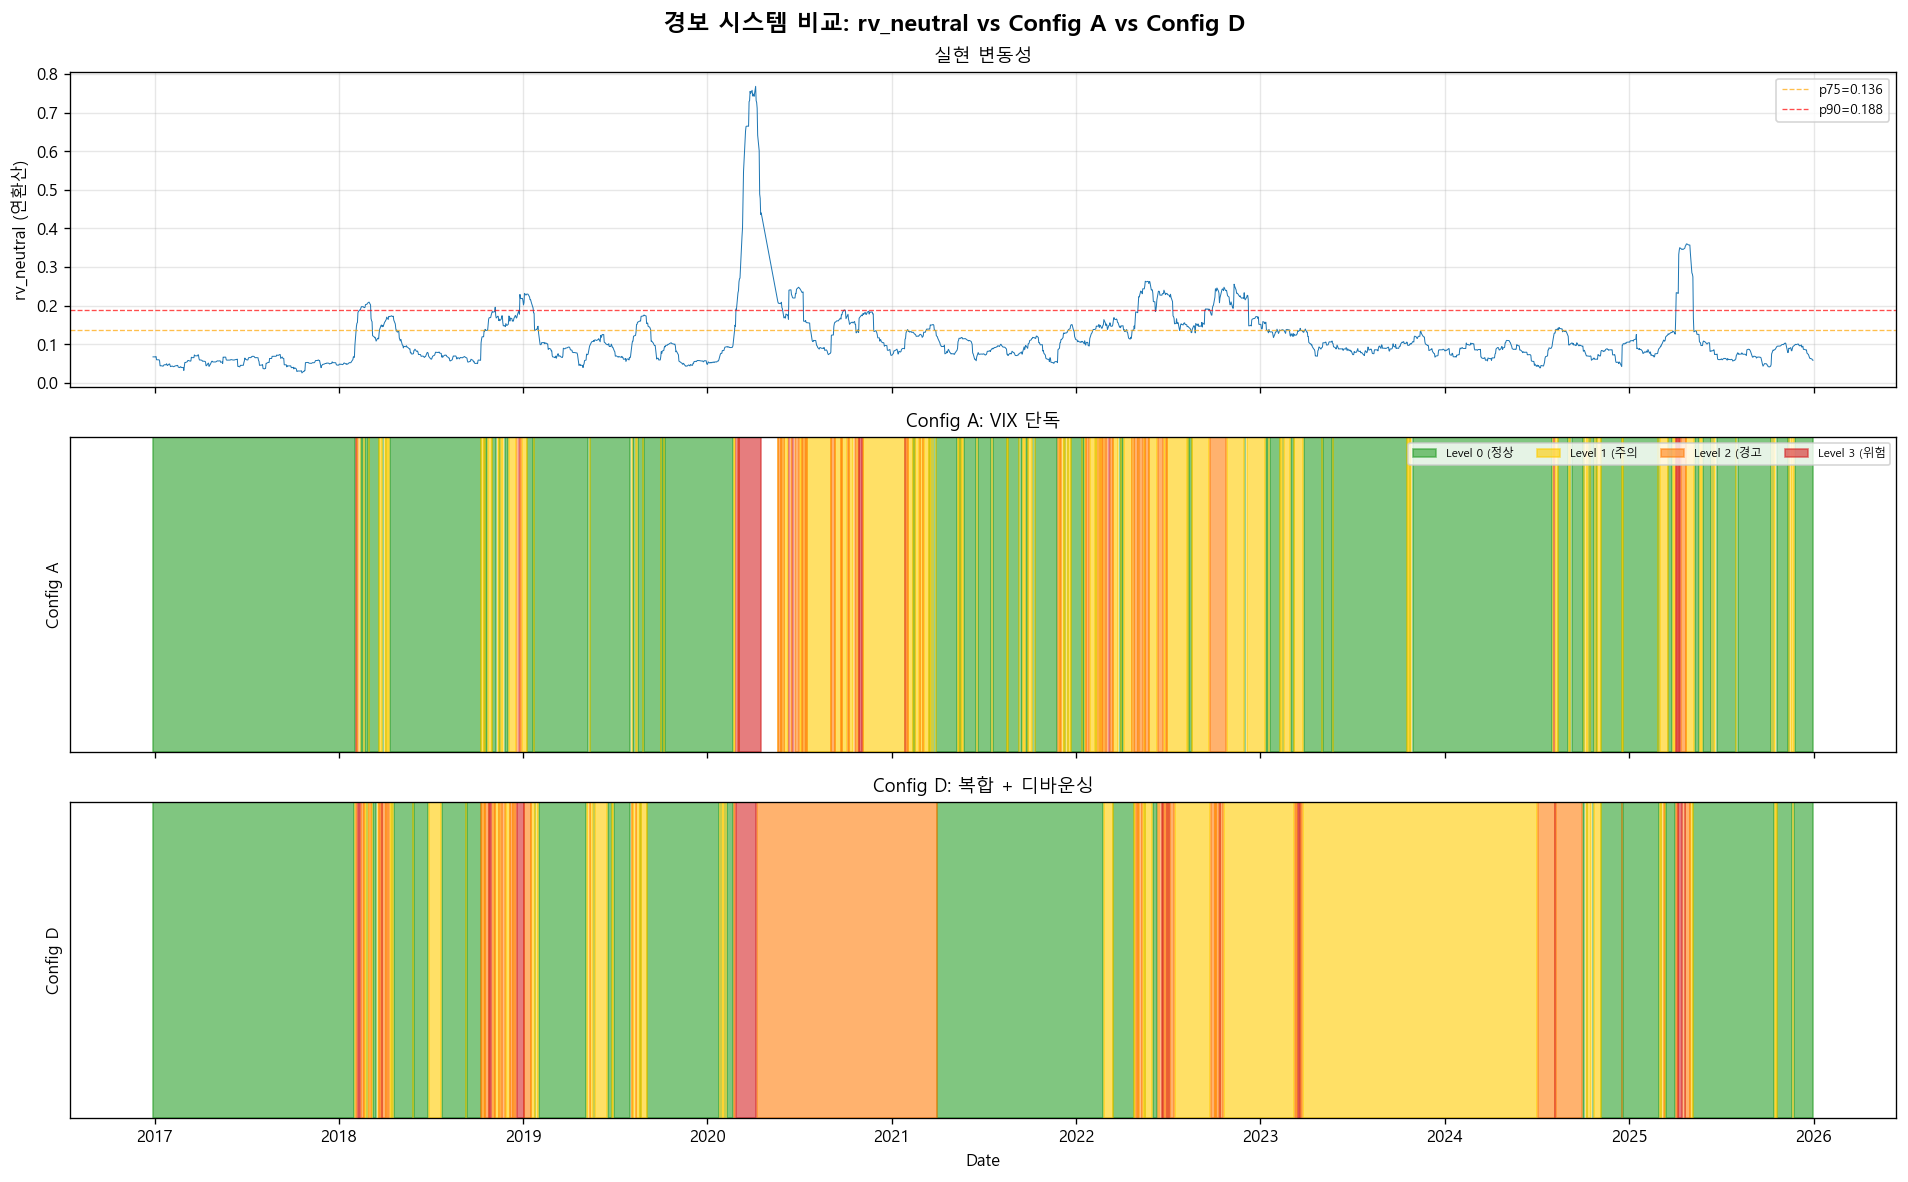

저장: images/step6_03_alert_comparison.png


In [8]:
# ============================================================
# 시각화: 경보 비교 타임라인 (rv_neutral / Config A / Config D)
# ============================================================

alert_colors = {0: '#2ca02c', 1: '#ffcc00', 2: '#ff7f0e', 3: '#d62728'}
alert_labels = {0: '정상', 1: '주의', 2: '경고', 3: '위험'}

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('경보 시스템 비교: rv_neutral vs Config A vs Config D', fontsize=14, fontweight='bold')

# ── subplot 1: rv_neutral ──
ax = axes[0]
rv = df_reg['rv_neutral'].dropna()
ax.plot(rv.index, rv.values, linewidth=0.6, color='#1f77b4')
ax.axhline(rv.quantile(0.75), color='orange', linestyle='--', linewidth=0.8, alpha=0.7, label=f'p75={rv.quantile(0.75):.3f}')
ax.axhline(rv.quantile(0.90), color='red', linestyle='--', linewidth=0.8, alpha=0.7, label=f'p90={rv.quantile(0.90):.3f}')
ax.set_ylabel('rv_neutral (연환산)')
ax.set_title('실현 변동성', fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)

# ── subplot 2: Config A ──
ax = axes[1]
for level in [0, 1, 2, 3]:
    mask = df_reg['alert_a'] == level
    if mask.any():
        ax.fill_between(df_reg.index, 0, 1, where=mask,
                        color=alert_colors[level], alpha=0.6, transform=ax.get_xaxis_transform())
ax.set_ylabel('Config A')
ax.set_title('Config A: VIX 단독', fontsize=11)
ax.set_yticks([])

# ── subplot 3: Config D ──
ax = axes[2]
for level in [0, 1, 2, 3]:
    mask = df_reg['alert_d'] == level
    if mask.any():
        ax.fill_between(df_reg.index, 0, 1, where=mask,
                        color=alert_colors[level], alpha=0.6, transform=ax.get_xaxis_transform())
ax.set_ylabel('Config D')
ax.set_title('Config D: 복합 + 디바운싱', fontsize=11)
ax.set_yticks([])
ax.set_xlabel('Date')

# 공통 범례
legend_patches = [mpatches.Patch(color=alert_colors[l], alpha=0.6, label=f'Level {l} ({alert_labels[l]}')
                  for l in [0, 1, 2, 3]]
axes[1].legend(handles=legend_patches, loc='upper right', fontsize=7, ncol=4)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step6_03_alert_comparison.png'), bbox_inches='tight')
plt.show()
print('저장: images/step6_03_alert_comparison.png')

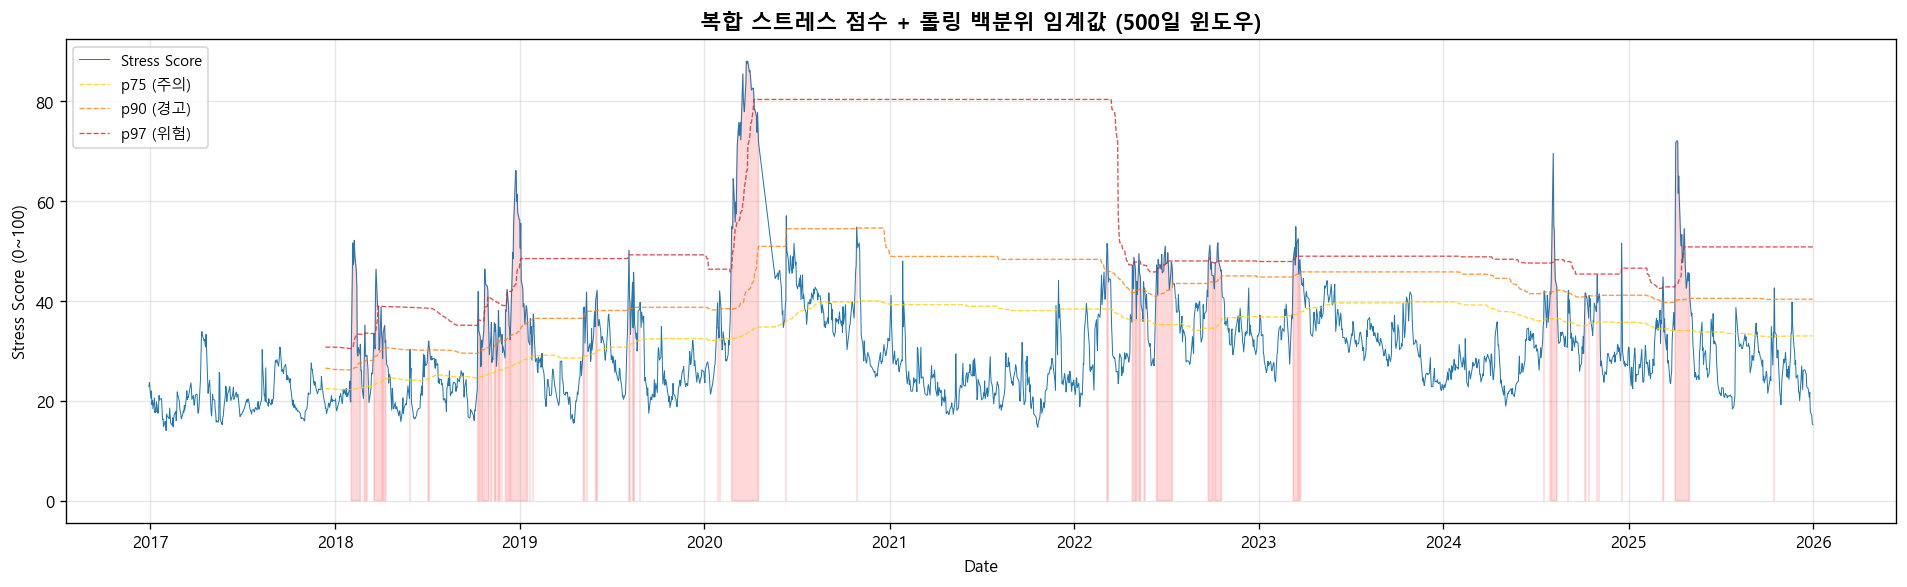

저장: images/step6_04_stress_score.png


In [9]:
# ============================================================
# 시각화: 스트레스 점수 타임라인 + 백분위 임계값
# ============================================================

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df_reg.index, df_reg['stress_score'], linewidth=0.6, color='#1f77b4', label='Stress Score')
ax.plot(rolling_p75.index, rolling_p75.values, linewidth=0.8, color='#ffcc00',
        linestyle='--', alpha=0.8, label='p75 (주의)')
ax.plot(rolling_p90.index, rolling_p90.values, linewidth=0.8, color='#ff7f0e',
        linestyle='--', alpha=0.8, label='p90 (경고)')
ax.plot(rolling_p97.index, rolling_p97.values, linewidth=0.8, color='#d62728',
        linestyle='--', alpha=0.8, label='p97 (위험)')

# 고스트레스 구간 음영
valid_mask = rolling_p90.notna()
high_stress = (df_reg['stress_score'] > rolling_p90) & valid_mask
ax.fill_between(df_reg.index, 0, df_reg['stress_score'],
                where=high_stress, color='red', alpha=0.15)

ax.set_ylabel('Stress Score (0~100)')
ax.set_xlabel('Date')
ax.set_title('복합 스트레스 점수 + 롤링 백분위 임계값 (500일 윈도우)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step6_04_stress_score.png'), bbox_inches='tight')
plt.show()
print('저장: images/step6_04_stress_score.png')

In [10]:
# ============================================================
# 경보 정밀도 평가 (Precision Evaluation)
# ============================================================

def evaluate_alerts(alert_series, rv_series, look_ahead=5):
    """
    경보 발생 후 look_ahead일 내에 고변동성(rv >= p75) 진입 여부 평가
    
    Parameters
    ----------
    alert_series : pd.Series - 경보 레벨 (>= 1이면 경보)
    rv_series : pd.Series - 실현 변동성
    look_ahead : int - 향후 관찰 기간 (영업일)
    
    Returns
    -------
    dict with total, hits, misses, precision, false_alarm
    """
    rv_75 = rv_series.quantile(0.75)
    alert_dates = alert_series[alert_series >= 1].index
    hits, misses = 0, 0
    
    for date in alert_dates:
        if date not in rv_series.index:
            continue
        loc = rv_series.index.get_loc(date)
        if loc + look_ahead >= len(rv_series):
            continue
        future_rv = rv_series.iloc[loc:loc + look_ahead].max()
        if future_rv >= rv_75:
            hits += 1
        else:
            misses += 1
    
    total = hits + misses
    return {
        'total': total,
        'hits': hits,
        'misses': misses,
        'precision': hits / total if total else 0,
        'false_alarm': misses / total if total else 0,
    }


# ── 4 Config 평가 ──
rv_valid = df_reg['rv_neutral'].dropna()

print('=' * 75)
print('경보 정밀도 평가 (경보 → 5일 내 rv_neutral >= p75 진입 여부)')
print(f'rv_neutral p75 = {rv_valid.quantile(0.75):.4f}')
print('=' * 75)

eval_results = []
for config in ['alert_a', 'alert_b', 'alert_c', 'alert_d']:
    alert_s = df_reg[config].reindex(rv_valid.index).dropna()
    result = evaluate_alerts(alert_s, rv_valid, look_ahead=5)
    result['config'] = config.upper()
    eval_results.append(result)

eval_df = pd.DataFrame(eval_results)[['config', 'total', 'hits', 'misses', 'precision', 'false_alarm']]
eval_df['precision'] = eval_df['precision'].map('{:.1%}'.format)
eval_df['false_alarm'] = eval_df['false_alarm'].map('{:.1%}'.format)
print(eval_df.to_string(index=False))

print('\n해석:')
print('  - Precision이 높을수록 경보 발생 시 실제 고변동성에 대응하는 비율이 높음')
print('  - False Alarm이 낮을수록 불필요한 경보가 적음')
print('  - Config D의 디바운싱은 노이즈 제거를 통해 False Alarm을 줄이는 데 기여')

경보 정밀도 평가 (경보 → 5일 내 rv_neutral >= p75 진입 여부)
rv_neutral p75 = 0.1358
 config  total  hits  misses precision false_alarm
ALERT_A    745   527     218     70.7%       29.3%
ALERT_B    760   533     227     70.1%       29.9%
ALERT_C   1229   593     636     48.3%       51.7%
ALERT_D   1166   580     586     49.7%       50.3%

해석:
  - Precision이 높을수록 경보 발생 시 실제 고변동성에 대응하는 비율이 높음
  - False Alarm이 낮을수록 불필요한 경보가 적음
  - Config D의 디바운싱은 노이즈 제거를 통해 False Alarm을 줄이는 데 기여


In [11]:
# ============================================================
# CSV 저장: regime_history.csv, alert_signals.csv
# ============================================================

# ── regime_history.csv ──
regime_cols = ['hmm_regime', 'VIX_level', 'VIX_contango', 'HY_spread', 'yield_curve',
               'Cu_Au_ratio_chg', 'rv_neutral']
regime_export = df_reg[regime_cols].dropna(subset=['hmm_regime'])
regime_export['hmm_regime'] = regime_export['hmm_regime'].astype(int)
regime_path = os.path.join(DATA_DIR, 'regime_history.csv')
regime_export.to_csv(regime_path)

# ── alert_signals.csv ──
alert_cols = ['alert_a', 'alert_b', 'alert_c', 'alert_d', 'stress_score',
              'VIX_level', 'VIX_contango', 'HY_spread', 'yield_curve', 'rv_neutral']
alert_export = df_reg[alert_cols].copy()
alert_export[['alert_a', 'alert_b', 'alert_c', 'alert_d']] = alert_export[['alert_a', 'alert_b', 'alert_c', 'alert_d']].astype(int)
alert_path = os.path.join(DATA_DIR, 'alert_signals.csv')
alert_export.to_csv(alert_path)

# ── 저장 확인 ──
print('=== CSV 저장 ===')
for fname, df_out in [('regime_history.csv', regime_export), ('alert_signals.csv', alert_export)]:
    path = os.path.join(DATA_DIR, fname)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {fname:30s} | {df_out.shape[0]:,}행 x {df_out.shape[1]:,}열 | {size_kb:.0f} KB')

print(f'\n저장 경로: {DATA_DIR}')
print('Step 6 완료.')

=== CSV 저장 ===
  regime_history.csv             | 2,328행 x 7열 | 226 KB
  alert_signals.csv              | 2,328행 x 10열 | 237 KB

저장 경로: C:\Users\gorhk\DA_Portfolio\01_Daily_Project\PJ12_Asset_Simulater\PJ12_v3_Final\data
Step 6 완료.
